## Introdução ao _Dataset_

O dataset escolhido foi produzido durante a minha pesquisa na bolsa PIBIC sobre Segurança em Redes Quânticas. O dataset possui um total de 22 features com cada uma representando um dado potencialmente coletado por um nó coordenador dessa rede de entrelaçamento.

O _dataset_ possui cerca de $960000$ linhas representando cada experimento

## _Features_
- Requests: Número de requests realizado na iteração
- Consumed EPRs: Consumo de Pares EPR
- Total Route Fidelity: Soma de todas as fidelidades das rotas
- Total Request Success: Número total de requests que resultaram em sucesso
- Total Request Fails: Número total de _requests_ que resultaram em falha
- Total No Paths: Total de requests que foram cancelados por não existir um caminho viável de um nó para o outro
- Total Route Length: Soma de todas as rotas da rede
- Total Request Attempts: Total de tentativas que o _request_ foi tentado antes de falhar (limite fixo)
- Total Entanglement Attempts: Total de tentativas de realização de _Entanglement_
- Total Swapping Attempts: Número total de tentativas de _entanglement swapping_ durante os requests
- Total Swapping Success: Número total de sucessos nos _entanglement swapping_
- Total Swapping Fails: Número total de falhas nos _entanglement swapping_
- Number of Nodes: Total de nós na rede
- Topology: Topologia escolhida na rede
- Simulation Time: Tempo total de simulação em ps no tempo do simulador
- Black Holes: Número de black holes
- Targets per Black Hole: Número de alvos por _black hole_
- Attack Type: Tipo do ataque
- Parameter: Parâmetro da topologia da rede
- Black Hole Swap Prob: Probabilidade de cada _black hole_ para o seu alvo ou rede inteira (depende da implementação)
- Normal Node Swap Prob: Probabilidade de cada nó normal da rede
- Intensity: Intensidade do ataque ($I = 1 - p_{black hole}$) em formato de string (apenas para facilitar a visualização)


### Instalação das bibliotecas necessárias

In [1]:
%pip install -q scikit-learn
%pip install -q seaborn
%pip install -q matplotlib
%pip install -q numpy
%pip install -q seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
^C
ERROR: Operation cancelled by user
Note: you may need to restart the kernel to use updated packages.


## Import das bibliotecas básicas

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from scipy.stats import norm
from time import time
from typing import Any

from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone

# Questão A: Seleção do dataset de acordo com o tema e aplicação de técnicas de aprendizado de máquina

O _dataset_ será limpo das features constantes ou extremamente redundantes para evitar processamento desnecessário pelos modelos e evitar plots desnecessários

O [_dataset_](https://drive.google.com/file/d/1OPBJy2zQcWIj4BD5-STpF0kfV0XtIZgC/view?usp=drive_link) por ser encontrado no drive por ser grande demais para caber no github

Observa-se que os valores de ataque e de redes normais tem a mesma proporção no _dataset_, assim, não é necessário a técnica de reamostragem

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/a/questao_1.png" width="900"/>

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/a/questao_2.png" width="900"/>

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/a/questao_3.png" width="900"/>

In [2]:
df: pd.DataFrame = pd.read_csv("default_simulation.csv")
df = df.drop(
  columns=[
    "Intensity", # removido por ser um dado string redundante

    # valores constantes
    "Total No Paths", # Não há possibilidade de existência de rota em grid
    "Requests", # o número de requests será sempre o mesmo
    "Topology", # a topologia sempre será a mesma
    "Parameter", # usado em outras topologias, na de grid é constante
    "Number of Nodes", # o número de nós nesse experimento é sempre igual a 12
    "Normal Node Swap Prob", # o valor de swap padrão sempre será constante para os nós (0.8)
  ]
)
df.head()

,Consumed EPRs,Total Route Fidelity,Total Request Success,Total Request Fails,Total Route Length,Total Request Attempts,Total Entanglement Attempts,Total Swapping Attempts,Total Swapping Success,Total Swapping Fails,Simulation Time,Black Holes,Targets per Black Hole,Attack Type,Black Hole Swap Prob
0,204,69.562883,85,15,301,137,407,102,81,21,5.090000e+13,0,0,0,-1.0
1,240,61.055595,76,24,329,147,455,120,93,27,5.750000e+13,0,0,0,-1.0
2,262,57.311575,73,27,337,148,496,131,105,26,6.270000e+13,0,0,0,-1.0
3,250,65.411694,81,19,324,145,455,125,96,29,5.800000e+13,0,0,0,-1.0
4,258,62.467489,78,22,319,145,499,129,101,28,6.280000e+13,0,0,0,-1.0


In [ ]:
df.info()

In [3]:
num_cols: int = len(df.columns)
layout: tuple[int, int] = (max(1, num_cols // 3 + (num_cols % 3 > 0)), 3)

print(f"Número de features após a limpeza: {num_cols}")

Número de features após a limpeza: 15


### O box plot das _features_

Os plots terão vários _outliers_ devido ao excesso de dados que temos dentro do arquivo csv, mas principalmente devido a alta aleatoriedade de redes quânticas na prática

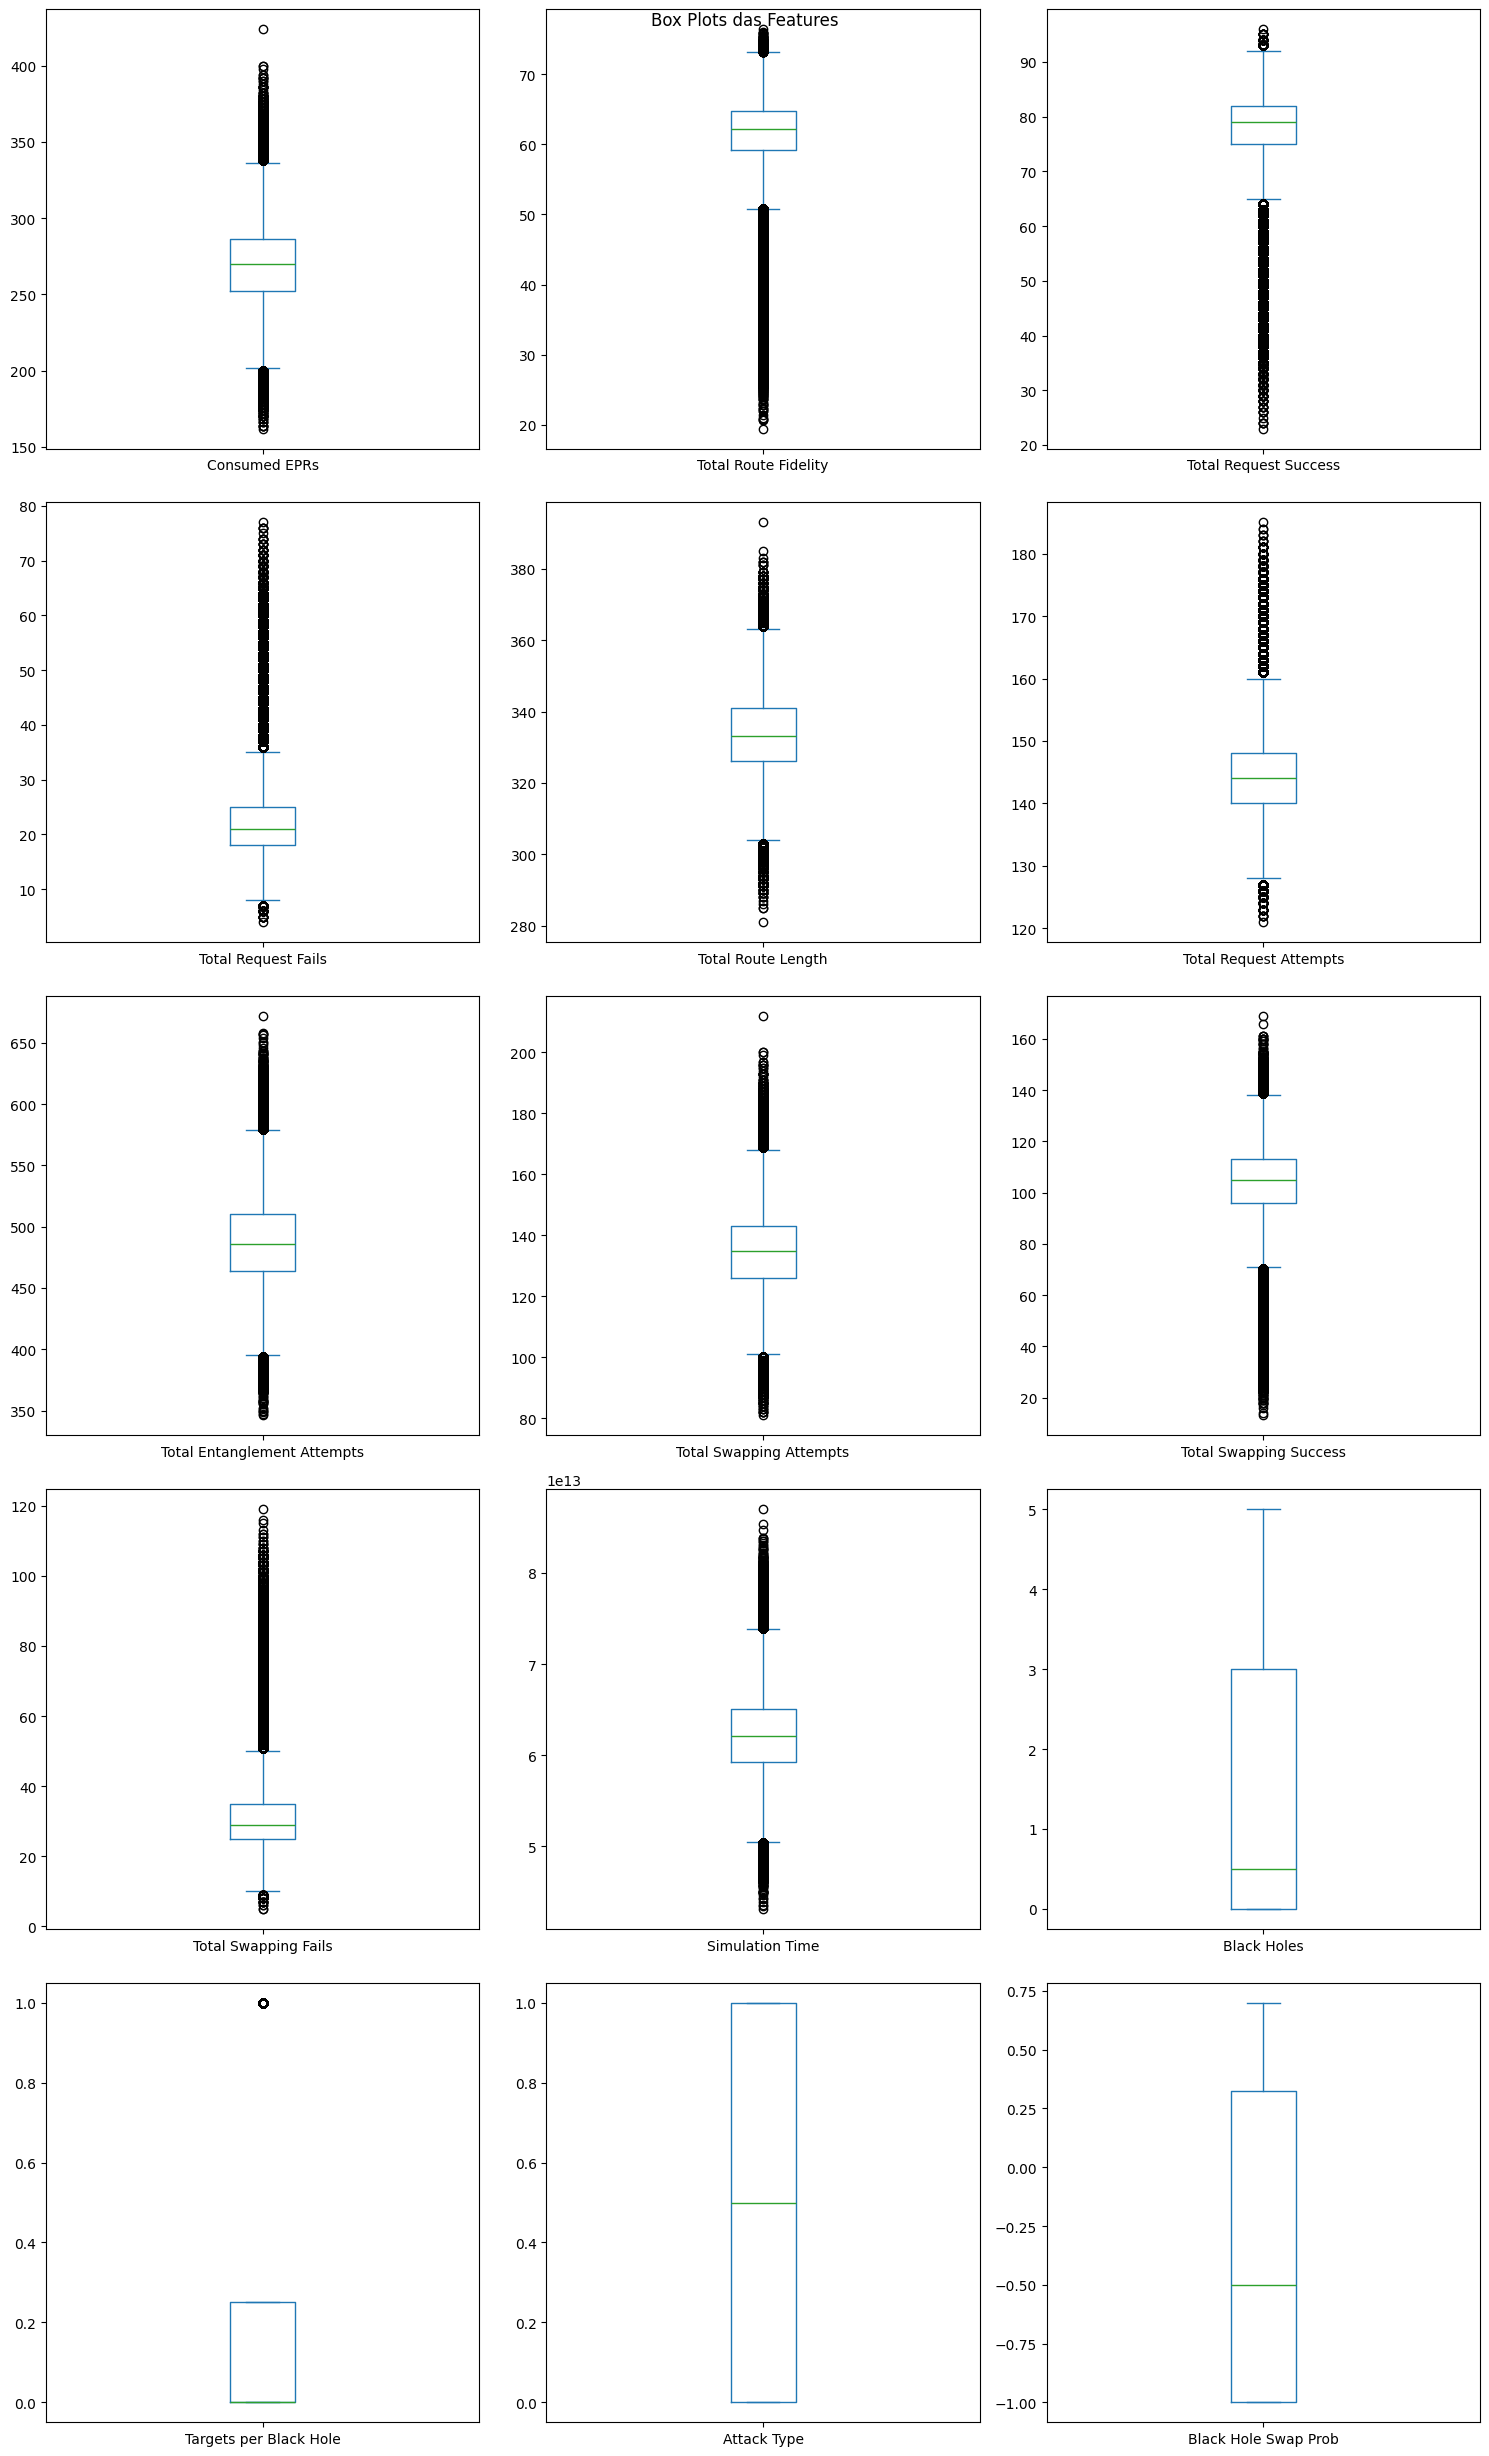

In [4]:
df.plot(
    kind='box',
    subplots=True,
    layout=layout,
    figsize=(15, 5 * layout[0]),
    sharex=False,
    sharey=False,
    title="Box Plots das Features"
)

plt.tight_layout()
plt.show()

### Split dos dados

In [5]:
# drop das colunas de resposta
X = df.drop(
  columns=[
    "Attack Type",
    "Targets per Black Hole",
    "Black Holes",
    "Black Hole Swap Prob"
  ]
)

# coluna de resposta
y = df["Attack Type"]

### Divisão com o kfold

In [6]:
RANDOM_STATE: int = 42 # a resposta do universo e tudo mais
KNN_NEIGHBORS: int = 5

cv_single = StratifiedKFold(
  n_splits=5,
  shuffle=True,
  random_state=RANDOM_STATE
)

scores_knn_single = []
scores_nb_single = []

### Utilização dos modelos para realização da comparação

A análise de dados demonstra que a acurácia de ambos os modelos não consegue com facilidade chegar aos $0.7$, demonstrando que não é um problema trivial para essas técnicas conseguirem interpretar

In [7]:
start_iterations_time: float = time()
for train_idx, test_idx in cv_single.split(X, y):
  start: float = time()
  X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # knn
  knn = KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS)
  knn.fit(X_train_scaled, y_train)
  scores_knn_single.append(knn.score(X_test_scaled, y_test))

  # naive bayes
  nb = GaussianNB()
  nb.fit(X_train_scaled, y_train)
  scores_nb_single.append(nb.score(X_test_scaled, y_test))
  print(f"Tempo total de iteração: {time()-start}")

print(f"Média de acurácia do KNN: {np.mean(scores_knn_single):.8f}")
print(f"Média de acurácio do NB: {np.mean(scores_nb_single):.8f}")
print(f"Tempo total de todas as iterações: {time()-start_iterations_time}")

Média de acurácia do KNN: 0.63343646
Média de acurácio do NB: 0.66114063


## Kfold para múltiplas execuções

In [8]:
cv_repeated = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)

scores_knn_repeated = []
scores_nb_repeated = []

## Execução das múltiplas execuções e salvamento dos dados

In [9]:
start_iterations_time: float = time()
for train_idx, test_idx in cv_repeated.split(X, y):
  start: float = time()
  X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # knn
  knn = KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS)
  knn.fit(X_train_scaled, y_train)
  scores_knn_repeated.append(knn.score(X_test_scaled, y_test))

  # naive bayes
  nb = GaussianNB()
  nb.fit(X_train_scaled, y_train)
  scores_nb_repeated.append(nb.score(X_test_scaled, y_test))
  print(f"Tempo total de iteração: {time()-start}")

print(f"Tempo total de todas as iterações: {time()-start_iterations_time}")

## Mostrando a comparação com _boxplots_

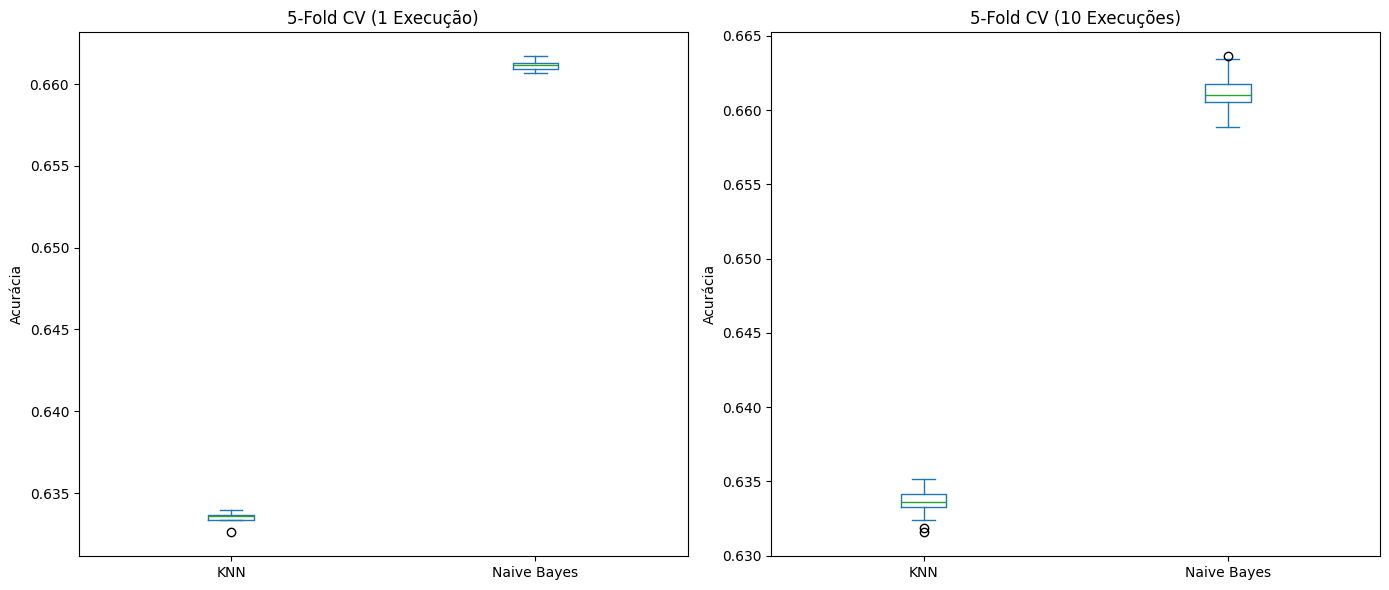

In [10]:
df_single = pd.DataFrame({
    'KNN': scores_knn_single,
    'Naive Bayes': scores_nb_single
})

df_repeated = pd.DataFrame({
    'KNN': scores_knn_repeated,
    'Naive Bayes': scores_nb_repeated
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_single.plot(kind='box', ax=axes[0], title='5-Fold CV (1 Execução)')
axes[0].set_ylabel('Acurácia')

df_repeated.plot(kind='box', ax=axes[1], title='5-Fold CV (10 Execuções)')
axes[1].set_ylabel('Acurácia')

plt.tight_layout()
plt.show()

## Cálculo da moda utilizando _Bins_

In [ ]:
def calculate_moda(scores_list, bins=10):
    hist, bin_edges = np.histogram(scores_list, bins=bins)
    max_idx = np.argmax(hist)
    return (bin_edges[max_idx], bin_edges[max_idx + 1])

print("----- 5-Fold cv (1 EXECUÇÃO) -----")
print(f"knn - média: {np.mean(scores_knn_single)}")
print(f"knn - moda: {calculate_moda(scores_knn_single)}")
print(f"nb  - média: {np.mean(scores_nb_single)}")
print(f"nb  - moda: {calculate_moda(scores_nb_single)}")

print("----- 5-FOld cv (10 EXECUÇÕES) -----")
print(f"knn - media: {np.mean(scores_knn_repeated)}")
print(f"knn - moda: {calculate_moda(scores_knn_repeated)}")
print(f"nb  - média: {np.mean(scores_nb_repeated)}")
print(f"nb  - moda: {calculate_moda(scores_nb_repeated)}")

# Questão B: Conceitos básicos de aprendizado de máquina

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/b/questao.png" width="900">

## Classes, Samples (Instâncias)

Classes representam as características (features) analisadas do _dataset_, normalmente são representadas pelas colunas da tabela. Os Samples (instâncias) representam as linhas da tabela, sendo justamente os dados agrupados de classes

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/b/classe.png" width="900">

## Pré-processamento, Aprendizado, Avaliação, Predição

### Pré-processamento (Preprocessing)

Essa etapa cuida fundamentalmente na higienização e estruturação da matemática de dados. Essa etapa visa transformar os dados brutos em entradas válidas para o modelo em questão, como matrizes numéricas ou vetores de números. Além disso, essa etapa também cuida da separação dos dados de treino e teste e também da normalização dos dados.

### Aprendizado (Learning)

Essa etapa é uma das mais cruciais, sendo a etapa responsável por inserir os dados pré-processados na etapa anterior no modelo. Essa etapa visa "ensinar" o modelo a inferir com os dados de treino que foram separados e tratados anteriormente. Essa etapa tenta maximizar a eficiência do modelo nos dados passados.

### Avaliação (Evaluetion)

Essa etapa busca validar o quanto a IA consegue identificar novos dados, tentando identificar qual a eficiência do modelo com os dados isolados para teste. Essa etapa irá utilizar de métricas para observar o quão bem o modelo consegue se sair com dados que o mesmo nunca entrou em contato

### Predição (Prediction)

Essa etapa é acontece após o modelo estar validado utilizando ele na prática. Ela baseia-se em expor o modelo a dados reais, ou seja, expor a dados que não estavam no _dataset_ o qual foi usado nas etapas anteriores.


<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/b/processo.png" width="900">

# C: Métricas

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/c/questao.png" width="900">

## Função para calcular todas as métricas de uma 

In [2]:
def calculate_metrics(df: pd.DataFrame, title: str) -> dict[str, float]:
    TN = df.iloc[0, 0]
    FP = df.iloc[0, 1]
    FN = df.iloc[1, 0]
    TP = df.iloc[1, 1]
    
    total = TN + FP + FN + TP
    
    accuracy = (TP + TN) / total
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"=== {title} ===")
    print(display(df))
    print(f"acuracia:  {accuracy}")
    print(f"precisao:  {precision}")
    print(f"recall:    {recall}")
    print(f"f1-score:  {f1}\n")
    
    return {"Acurácia": accuracy, "Precisão": precision, "Recall": recall, "F1-Score": f1}

rows = ['Real Negativo (0)', 'Real Positivo (1)']
columns = ['Predito Negativo (0)', 'Predito Positivo (1)']

## Matriz confusão

Matriz confusão está relacionado a uma forma visual de como os dados preditos e os dados reais se comportam. Sendo a linha e a coluna representando, respectivamente, Os dados previstos e os dados reais. Essa forma de visualização é muito útil para entender como o modelo está se adptando aos dados

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/c/confusao.webp" width="900">

## Acurácia

Essa métrica mede o quanto de verdadeiros positivos o modelo encontrou em relação ao total de dados passado. Ela pode ser observada pela fórmula

$$
\text{Acurácia} = \frac{\text{TP}+\text{TN}}{\text{TP}+\text{TN}+\text{FP}+\text{FN}}
$$

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/c/accuracy.png" width="900">

In [3]:
# balanceado
matrix_good_accuracy = pd.DataFrame([[450, 50], 
                                 [50, 450]], index=rows, columns=columns)
calculate_metrics(matrix_good_accuracy, "Acurácia - Cenário Ideal Balanceado")

# desbalanceado: o modelo chutou poucos e acertou
matrix_bad_accuracy = pd.DataFrame([[990, 0], 
                                [10, 0]], index=rows, columns=columns)
calculate_metrics(matrix_bad_accuracy, "Acurácia - Desvantagem (Dados Desbalanceados)")

=== Acurácia - Cenário Ideal Balanceado ===


,Predito Negativo (0),Predito Positivo (1)
Real Negativo (0),450,50
Real Positivo (1),50,450


None
acuracia:  0.9
precisao:  0.9
recall:    0.9
f1-score:  0.9

=== Acurácia - Desvantagem (Dados Desbalanceados) ===


,Predito Negativo (0),Predito Positivo (1)
Real Negativo (0),990,0
Real Positivo (1),10,0


None
acuracia:  0.99
precisao:  0
recall:    0.0
f1-score:  0



{'Acurácia': np.float64(0.99),
 'Precisão': 0,
 'Recall': np.float64(0.0),
 'F1-Score': 0}

## Precisão

Precisão é a métrica que analisa o quanto o modelo consegue com tudo que o modelo disse que era positivo. Sua fórmula pode ser dada por

$$
\text{Precisão} = \frac{\text{TP}}{\text{TP}+\text{FP}}
$$

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/c/precision.png" width="900">

In [ ]:
# equilibrado
matrix_good_precision = pd.DataFrame([[400, 20], 
                                  [30, 150]], index=rows, columns=columns)
calculate_metrics(matrix_good_precision, "Precisão - Cenário Ideal")

# o modelo chutou somente 1 e acertou
matrix_bad_precision = pd.DataFrame([[900, 0], 
                                 [99, 1]], index=rows, columns=columns)
calculate_metrics(matrix_bad_precision, "Precisão - Desvantagem (Ignora Falsos Negativos)")

## Recall (Sensibilidade)

Recall é o quanto de dados positivos reais que o modelo foi capaz de encontrar e classificar exatamente. Sua fórmula pode ser dada por:

$$
\text{Recall} = \frac{\text{TP}}{\text{TP}+\text{FN}}
$$

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/c/recall.webp" width="900">

In [6]:
# equilibrado
matrix_good_recall = pd.DataFrame([[380, 40], 
                                 [15, 165]], index=rows, columns=columns)
calculate_metrics(matrix_good_recall, "Recall - Cenário Ideal")

# o modelo chutou tudo positivo
matrix_bad_recall = pd.DataFrame([[0, 900], 
                                [0, 100]], index=rows, columns=columns)
calculate_metrics(matrix_bad_recall, "Recall - Desvantagem (Ignora Falsos Positivos)")

=== Recall - Cenário Ideal ===


,Predito Negativo (0),Predito Positivo (1)
Real Negativo (0),380,40
Real Positivo (1),15,165


None
acuracia:  0.9083333333333333
precisao:  0.8048780487804879
recall:    0.9166666666666666
f1-score:  0.8571428571428571

=== Recall - Desvantagem (Ignora Falsos Positivos) ===


,Predito Negativo (0),Predito Positivo (1)
Real Negativo (0),0,900
Real Positivo (1),0,100


None
acuracia:  0.1
precisao:  0.1
recall:    1.0
f1-score:  0.18181818181818182



{'Acurácia': np.float64(0.1),
 'Precisão': np.float64(0.1),
 'Recall': np.float64(1.0),
 'F1-Score': np.float64(0.18181818181818182)}

## F1-Score

É a média entre a precisão e o recall, ela busca tentar punir os desequilíbrios que podem ocultar o verdadeiro comportamento nas outras métricas. Sua fórmula é dada por:

$$
\text{F1} = \frac{\text{Recall} \times \text{Precisâo}}{\text{Precisão}+\text{Recall}}
$$

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/c/f1.png" width="900">

In [8]:
# balanceado
matrix_good_f1 = pd.DataFrame([[450, 20], 
                                [25, 200]], index=rows, columns=columns)
calculate_metrics(matrix_good_f1, "F1-Score - Cenário Equilibrado")

# não sente verdadeiros negativos
matrix_bad_f1 = pd.DataFrame([[10, 20], 
                               [25, 200]], index=rows, columns=columns)
calculate_metrics(matrix_bad_f1, "F1-Score - Desvantagem (Insensibilidade a Verdadeiros Negativos)")

=== F1-Score - Cenário Equilibrado ===


,Predito Negativo (0),Predito Positivo (1)
Real Negativo (0),450,20
Real Positivo (1),25,200


None
acuracia:  0.935251798561151
precisao:  0.9090909090909091
recall:    0.8888888888888888
f1-score:  0.8988764044943819

=== F1-Score - Desvantagem (Insensibilidade a Verdadeiros Negativos) ===


,Predito Negativo (0),Predito Positivo (1)
Real Negativo (0),10,20
Real Positivo (1),25,200


None
acuracia:  0.8235294117647058
precisao:  0.9090909090909091
recall:    0.8888888888888888
f1-score:  0.8988764044943819



{'Acurácia': np.float64(0.8235294117647058),
 'Precisão': np.float64(0.9090909090909091),
 'Recall': np.float64(0.8888888888888888),
 'F1-Score': np.float64(0.8988764044943819)}

# D: Comparando Naive Bayes e KNN com Estratégias Diferentes de Normalização usando o Dataset Iris

Essa questão não terá os 15 slides de comando inseridas nela para fins de diminuir o peso do jupyter notebook e facilitar que o google colab consiga resolver os dados sem ser desconectado do servidor. Essa foi a soluação encontrada para reduzir o peso excessivo do arquivo

## Pré-processamento de carregamento de dados

In [36]:
iris: Any = load_iris()
X: np.ndarray = iris.data
y: np.ndarray = iris.target
class_names: list[str] = iris.target_names.tolist()

print(f"Total de amostras: {X.shape[0]}")
print(f"Total de features: {X.shape[1]}")
print(f"Classes alvo: {class_names}")

Total de amostras: 150
Total de features: 4
Classes alvo: ['setosa', 'versicolor', 'virginica']


In [37]:
def evaluate_pipeline(
    model: Any, 
    X_data: np.ndarray, 
    y_data: np.ndarray, 
    scalers: list[Any], 
    simulate_leakage: bool = False
) -> dict[str, Any]:
  
  # utilizando 5 folds (k)
  skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  
  metrics: dict[str, list[float]] = {
      'accuracy': [], 'precision': [], 'recall': [], 'f1': []
  }
  confusion_matrices: list[np.ndarray] = []
  
  # simulando vazamento de dados
  X_leaked: np.ndarray = np.copy(X_data)
  if simulate_leakage and scalers:
    for scaler in scalers:
      X_leaked = scaler.fit_transform(X_leaked)

  for train_idx, test_idx in skf.split(X_data, y_data):
    X_train: np.ndarray = X_data[train_idx]
    X_test: np.ndarray = X_data[test_idx]
    y_train: np.ndarray = y_data[train_idx]
    y_test: np.ndarray = y_data[test_idx]
    
    # cenário sem vazamneto
    if not simulate_leakage and scalers:
      for scaler in scalers:
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
    # substitui a matriz corrompida se tiver vazamento
    if simulate_leakage:
      X_train = X_leaked[train_idx]
      X_test = X_leaked[test_idx]

    # treinamento e predição
    current_model = clone(model)
    current_model.fit(X_train, y_train)
    y_pred: np.ndarray = current_model.predict(X_test)
    
    metrics['accuracy'].append(accuracy_score(y_test, y_pred))
    metrics['precision'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    metrics['recall'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    metrics['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    confusion_matrices.append(confusion_matrix(y_test, y_pred))
    
  return {
    'mean_accuracy': np.mean(metrics['accuracy']),
    'mean_precision': np.mean(metrics['precision']),
    'mean_recall': np.mean(metrics['recall']),
    'mean_f1': np.mean(metrics['f1']),
    'mean_cm': np.mean(confusion_matrices, axis=0)
  }

## Execução e comparação

Essa célula executa 3 estratégias de pré-processamento para os dois classificadores utilizando o scaler sem treinar com os dados de teste. Esse comportamento é essencial para uma avaliação do modelo sem enviezamento

In [38]:
# carregando os dois modelos
models: dict[str, Any] = {
    "Naive Bayes": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

# estrategias de pre-processamento
preprocessing_strategies: dict[str, list[Any]] = {
    "Padrão (sem estratégia)": [],
    "Min-Max": [MinMaxScaler()],
    "Z-Score": [StandardScaler()],
    "Z-Score + Min-Max": [StandardScaler(), MinMaxScaler()]
}

print("---- Avaliação sem vazamento de dados ----")

for model_name, model in models.items():
    print(f"--- Modelo: {model_name} ---")
    for prep_name, scalers in preprocessing_strategies.items():
        results = evaluate_pipeline(model, X, y, scalers, simulate_leakage=False)
        print(f"Estratégia: {prep_name}")
        print(f"Acurácia: {results['mean_accuracy']:.4f} | F1-Score: {results['mean_f1']:.4f}")
    print()

---- Avaliação sem vazamento de dados ----
--- Modelo: Naive Bayes ---
Estratégia: Padrão (sem estratégia)
  Acurácia: 0.9467 | F1-Score: 0.9465
Estratégia: Min-Max
  Acurácia: 0.9467 | F1-Score: 0.9465
Estratégia: Z-Score
  Acurácia: 0.9467 | F1-Score: 0.9465
Estratégia: Z-Score + Min-Max
  Acurácia: 0.9467 | F1-Score: 0.9465

--- Modelo: KNN (k=5) ---
Estratégia: Padrão (sem estratégia)
  Acurácia: 0.9667 | F1-Score: 0.9666
Estratégia: Min-Max
  Acurácia: 0.9600 | F1-Score: 0.9599
Estratégia: Z-Score
  Acurácia: 0.9733 | F1-Score: 0.9733
Estratégia: Z-Score + Min-Max
  Acurácia: 0.9600 | F1-Score: 0.9599



## Simulação com vazamento de dados

Essa simulação utiliza o scaler em todo o dataset antes de dar o split, fazendo com que os dados de teste vazem para os dados de treino, facilitando para que o modelo se dê bem nos teste. Esse comportamento deve ser evitado, pois na realidade os dados de treino nunca serão os mesmos da realidade e o modelo só estará artificialmente melhor nas métricas por meio do overfitting

In [39]:
print("---- Simulação com vazamento de dadso ----")

for model_name, model in models.items():
    print(f"-=-=- Modelo: {model_name} -=-=-")
    for prep_name, scalers in preprocessing_strategies.items():
        if not scalers: # pula se não tiver um scaler
          continue 
        
        results = evaluate_pipeline(model, X, y, scalers, simulate_leakage=True)
        print(f"Estratégia: {prep_name}")
        print(f"Acurácia: {results['mean_accuracy']} | F1-Score: {results['mean_f1']}")
    print()

---- Simulação com vazamento de dadso ----
-=-=- Modelo: Naive Bayes -=-=-
Estratégia: Min-Max
Acurácia: 0.9466666666666667 | F1-Score: 0.9465329991645781
Estratégia: Z-Score
Acurácia: 0.9466666666666667 | F1-Score: 0.9465329991645781
Estratégia: Z-Score + Min-Max
Acurácia: 0.9466666666666667 | F1-Score: 0.9465329991645781

-=-=- Modelo: KNN (k=5) -=-=-
Estratégia: Min-Max
Acurácia: 0.9600000000000002 | F1-Score: 0.9599331662489557
Estratégia: Z-Score
Acurácia: 0.9666666666666666 | F1-Score: 0.9665831244778612
Estratégia: Z-Score + Min-Max
Acurácia: 0.9600000000000002 | F1-Score: 0.9599331662489557



# E: Classificador KNN no Conjunto de Dados Íris usando Curvas ROC

Devido ao excesso de slides dessa questão, não inseri eles no notebook para que ele não ultrapassasse um limite de tamanho para que o google colab consiga rodar com menos erros. Essa foi a solução para não adicionar 7 imagens pesadas a questão

## Pré-processamento dos dados

Nessa etapa carregamos o iris e tratamos ele para que possamos usar no nosso código

In [26]:
iris = load_iris()

# sepal length e sepal width)
X: np.ndarray = iris.data[:, :2]

# 1 se for 'versicolor' (índice 1 no dataset Iris), 0 caso contrário ("não versicolor").
y: np.ndarray = (iris.target == 1).astype(int)

print(f"Formato de X: {X.shape}")
print(f"Total de amostras positivas (versicolor): {sum(y == 1)}")
print(f"Total de amostras negativas: {sum(y == 0)}")

Formato de X: (150, 2)
Total de amostras positivas (versicolor): 50
Total de amostras negativas: 100


## Split dos dados de treino e teste

In [27]:
X_train: np.ndarray
X_test: np.ndarray
y_train: np.ndarray
y_test: np.ndarray

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]}")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]}")

Tamanho do conjunto de treino: 105
Tamanho do conjunto de teste: 45


## Iteração sobre K

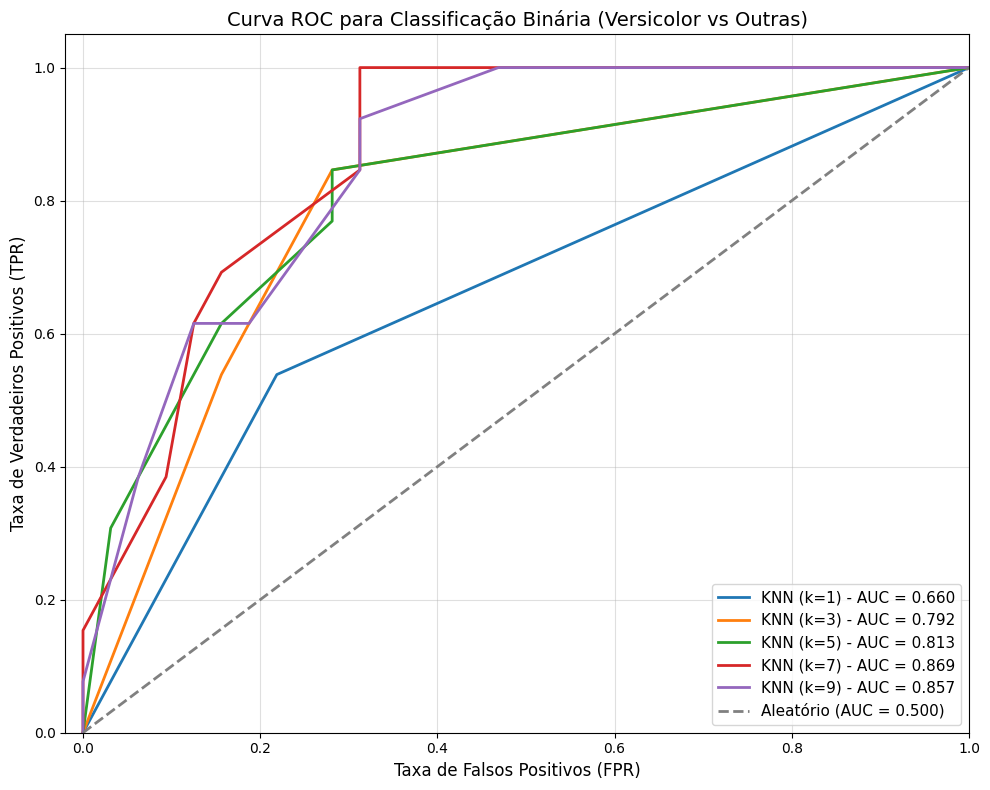

In [30]:
k_values: list[int] = [1, 3, 5, 7, 9]

plt.figure(figsize=(10, 8))

for k in k_values:
  # treinamento do knn
  knn: KNeighborsClassifier = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  
  # probabilidade de pertencer a classe positiva (1)
  y_prob: np.ndarray = knn.predict_proba(X_test)[:, 1]
  
  # pontos da curva ROC e a AUC
  fpr, tpr, thresholds = roc_curve(y_test, y_prob)
  roc_auc: float = auc(fpr, tpr)
  
  # curva do k atual
  plt.plot(fpr, tpr, lw=2, label=f'KNN (k={k}) - AUC = {roc_auc:.3f}')

# adicionando a linha base (classificador aleatorio)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Aleatório (AUC = 0.500)')

plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.title('Curva ROC para Classificação Binária (Versicolor vs Outras)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Análise

Observando os valores de AUC, podemos inferir a capacidade do modelo de distinguir a classe versicolor do restante usando apenas as features Sepal Length e Sepal Width.

Conforme o K fica maior, o valor de bias cresce, mas a variância reduz. Isso demonstra o quanto esse K deve ser escolhido com cuidado

# F: Curva ROC

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/f/questao_1.png" width="900">

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/f/questao_2.png" width="900">

## Inicialização dos dados

Os dados dos ratinhos foram iniciados manualmente e não dava para saber pelos slides quais eram os ratinhos obesos e quais não eram, então foi considerado o primeiro grupo como ratinhos com peso normal e o segundo grupo como obesos

In [18]:
normal_weight_rats: np.ndarray = np.array([
  450, 455,
  470, 660,
])

weight_obese_rats: np.ndarray = np.array([
  575, 665,
  700, 710
])

X: np.ndarray = np.concatenate([normal_weight_rats, weight_obese_rats]).reshape(-1, 1)
# inicializando manualmente os dados de resposta
y: np.ndarray = np.concatenate([np.zeros(len(normal_weight_rats)), np.ones(len(weight_obese_rats))])

## Inicialização e treino do modelo

Realizamos a inicialização do modelo de regressão logística

In [19]:
model = LogisticRegression()
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Inicialização de dados consecutivos para o modelo sentir o aumento da probabilidade

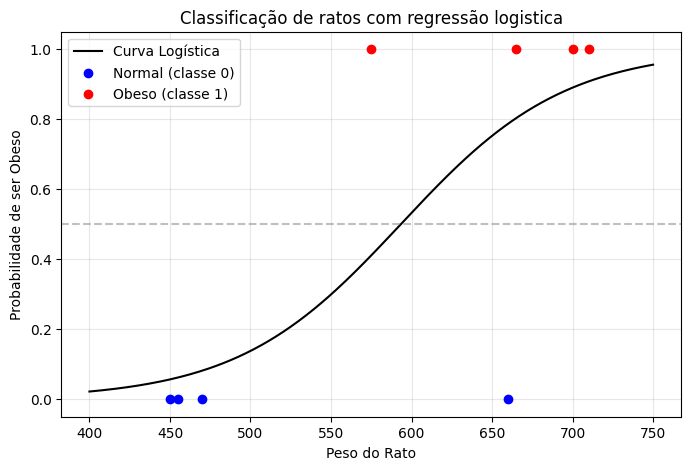

In [20]:
X_test = np.linspace(400, 750, 300).reshape(-1, 1)
y_prob = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))
plt.plot(X_test, y_prob, color='black', label='Curva Logística')
plt.scatter(normal_weight_rats, np.zeros(len(normal_weight_rats)), color='blue', label='Normal (classe 0)', zorder=5)
plt.scatter(weight_obese_rats, np.ones(len(weight_obese_rats)), color='red', label='Obeso (classe 1)', zorder=5)

plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Peso do Rato')
plt.ylabel('Probabilidade de ser Obeso')
plt.title('Classificação de ratos com regressão logistica')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Criando a curva ROC de forma iterativa

iteração | Prob | TP | FP | TN | FN |  FPR |  TPR
     0   |    1.0080     | 0  | 0  | 4  | 4  | 0.00 | 0.00
     1   |    0.9080     | 1  | 0  | 4  | 3  | 0.00 | 0.25
     2   |    0.8903     | 2  | 0  | 4  | 2  | 0.00 | 0.50
     3   |    0.8032     | 3  | 0  | 4  | 1  | 0.00 | 0.75
     4   |    0.7872     | 3  | 1  | 3  | 1  | 0.25 | 0.75
     5   |    0.4110     | 4  | 1  | 3  | 0  | 0.25 | 1.00
     6   |    0.0816     | 4  | 2  | 2  | 0  | 0.50 | 1.00
     7   |    0.0621     | 4  | 3  | 1  | 0  | 0.75 | 1.00
     8   |    0.0566     | 4  | 4  | 0  | 0  | 1.00 | 1.00


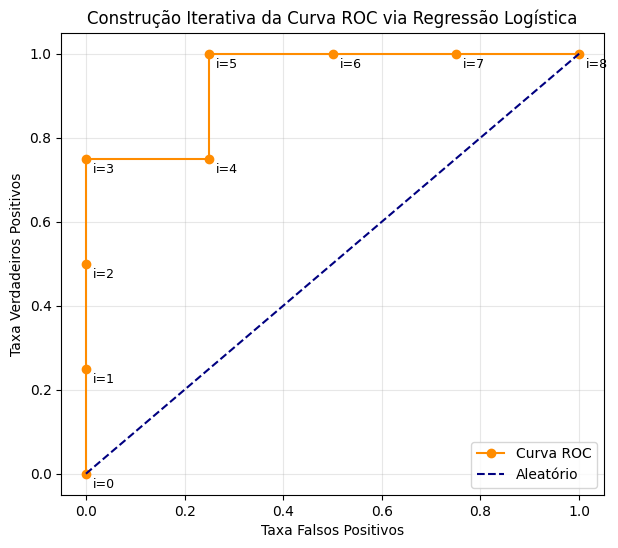

In [21]:
probs = model.predict_proba(X)[:, 1]

thresholds = np.sort(np.unique(probs))[::-1]
thresholds = np.insert(thresholds, 0, thresholds[0] + 0.1)

fpr_list = []
tpr_list = []

print("iteração | Prob | TP | FP | TN | FN |  FPR |  TPR")

for i, t in enumerate(thresholds):
    y_pred = (probs >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    tpr_list.append(tpr)
    fpr_list.append(fpr)

    print(f"   {i:^5d} | {t:^13.4f} | {tp:^2d} | {fp:^2d} | {tn:^2d} | {fn:^2d} | {fpr:.2f} | {tpr:.2f}")

# curva ROC
plt.figure(figsize=(7, 6))
plt.plot(fpr_list, tpr_list, marker='o', linestyle='-', color='darkorange', label='Curva ROC')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy', label='Aleatório')

# texto de cada ponto para identificar as iterações
for i, (fpr, tpr) in enumerate(zip(fpr_list, tpr_list)):
    plt.annotate(f'i={i}', (fpr, tpr), textcoords="offset points", xytext=(5,-10), ha='left', fontsize=9)

plt.xlabel('Taxa Falsos Positivos')
plt.ylabel('Taxa Verdadeiros Positivos')
plt.title('Construção Iterativa da Curva ROC via Regressão Logística')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# G - Naive Bayes and Spam

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/g/questao_1.png" width="900">

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/g/questao_2.png" width="900">

In [3]:
emails_numbers: dict[str, int] = {
  "Dear": 9,
  "Friend": 6,
  "Lunch": 4,
  "Money": 2
}

emails_len: int = sum([v for k, v in emails_numbers.items()])
emails_probs: dict[str, float] = {
  k: v / emails_len for k, v in emails_numbers.items()
}

spams_numbers: dict[str, int] = {
  "Dear": 3,
  "Friend": 2,
  "Lunch": 1,
  "Money": 5
}

spams_len: int = sum([v for k, v in spams_numbers.items()])
spams_probs: dict[str, float] = {
  k: v / spams_len for k, v in spams_numbers.items()
}

spam_prob: float = spams_len / (spams_len + emails_len)
email_prob: float = 1.0 - spam_prob

## Função

Essa função tenta simular o comportamento do Naive Bayes calculando as duas possibilidades, uma de ser spam e outra de não ser

A fórmula vira:
$$
P_{spam} = p(S) \times p(\text{lunch} | S) \times p(\text{money} | S)^4
$$

e o de ser email

$$
P_{email} = p(E) \times p(\text{lunch} | E) \times p(\text{money} | E)^4
$$

In [4]:
def calc_probs(words: str, emails_probs: dict[str, float], spam_probs: dict[str, float], email_prob: float, spam_prob: float) -> tuple[float, float]:
  words_list: list[str] = words.split(" ")
  result: list[float] = [email_prob, spam_prob]

  for word in words_list:
    result[0] *= emails_probs[word]

  for word in words_list:
    result[1] *= spams_probs[word]

  if result[0] >= result[1]:
    print(f"O email é um email. Chance de ser email normal é {result[0]} e de ser spam é {result[1]}")
  else:
    print(f"O email é um spam. Chance de ser email normal é {result[0]} e de ser spam é {result[1]}")

  return result[0], result[1]

## Resultados

Os resultados demonstram que a probabilidade desse email ser spam é bem maior que a chance de ser um email comum.

In [5]:
calc_probs("Lunch Money Money Money Money", emails_probs, spams_probs, email_prob, spam_prob)

O email é um spam. Chance de ser email normal é 1.0283780934898523e-05 e de ser spam é 0.0013340106550099034


(1.0283780934898523e-05, 0.0013340106550099034)

# H - Gauss Naive Bayes dos slides

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/h/questao_1.png" width="900">

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/h/questao_2.png" width="900">


## Definindo a distribuição e o RNG

Como os dados não foram passados no slide, então foi considerado o valor do livro do apresentador do vídeo

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/h/livro.png" width="500">

In [13]:
RANDOM_STATE: int = 42
SAMPLE_SIZE: int = 1000

rng = np.random.default_rng(RANDOM_STATE)

like_trolls_popcorn: np.ndarray = rng.normal(loc=24, scale=4.0, size=SAMPLE_SIZE)
like_trolls_soda: np.ndarray = rng.normal(loc=500, scale=100.0, size=SAMPLE_SIZE)
like_trolls_candy: np.ndarray = rng.normal(loc=25, scale=5.0, size=SAMPLE_SIZE)

not_like_trolls_popcorn: np.ndarray = rng.normal(loc=4, scale=2.0, size=SAMPLE_SIZE)
not_like_trolls_soda: np.ndarray = rng.normal(loc=220, scale=100.0, size=SAMPLE_SIZE)
not_like_trolls_candy: np.ndarray = rng.normal(loc=100, scale=20.0, size=SAMPLE_SIZE)

## Mostrando em formato de tabela

In [14]:
like_trolls_df: pd.DataFrame = pd.DataFrame({
    "popcorn": like_trolls_popcorn,
    "soda": like_trolls_soda,
    "candy": like_trolls_candy,
})

like_trolls_df.head()

,popcorn,soda,candy
0,25.218868,494.071735,22.740245
1,19.840064,427.071306,21.670611
2,27.001805,458.552693,27.170049
3,27.762259,563.391038,26.259272
4,16.195859,500.299329,17.976042


In [15]:
not_like_trolls_df: pd.DataFrame = pd.DataFrame({
    "popcorn": not_like_trolls_popcorn,
    "soda": not_like_trolls_soda,
    "candy": not_like_trolls_candy,
})

not_like_trolls_df.head()

,popcorn,soda,candy
0,6.498045,245.320451,94.840958
1,5.375384,309.521840,94.010282
2,7.932255,247.332126,86.066802
3,0.904334,443.883167,108.569659
4,3.469280,362.978745,104.692924


## Adição de uma nova pessoa e cálculo do likelihood

Nós adicionamos uma nova pessoa com valores retirados do slide para o seu gosto. Com base nas curvas

In [16]:
new_person_popcorn: float = 20.0
new_person_soda: float = 500.0
new_person_candy: float = 25.0

like_likelihood_popcorn: np.ndarray = norm.pdf(new_person_popcorn, like_trolls_popcorn.mean(), like_trolls_popcorn.std())
like_likelihood_soda: np.ndarray = norm.pdf(new_person_soda, like_trolls_soda.mean(), like_trolls_soda.std())
like_likelihood_candy: np.ndarray = norm.pdf(new_person_candy, like_trolls_candy.mean(), like_trolls_candy.std())

not_like_likelihood_popcorn: np.ndarray = norm.pdf(new_person_popcorn, not_like_trolls_popcorn.mean(), not_like_trolls_popcorn.std())
not_like_likelihood_soda: np.ndarray = norm.pdf(new_person_soda, not_like_trolls_soda.mean(), not_like_trolls_soda.std())
not_like_likelihood_candy: np.ndarray = norm.pdf(new_person_candy, not_like_trolls_candy.mean(), not_like_trolls_candy.std())

## Plotagem dos dados

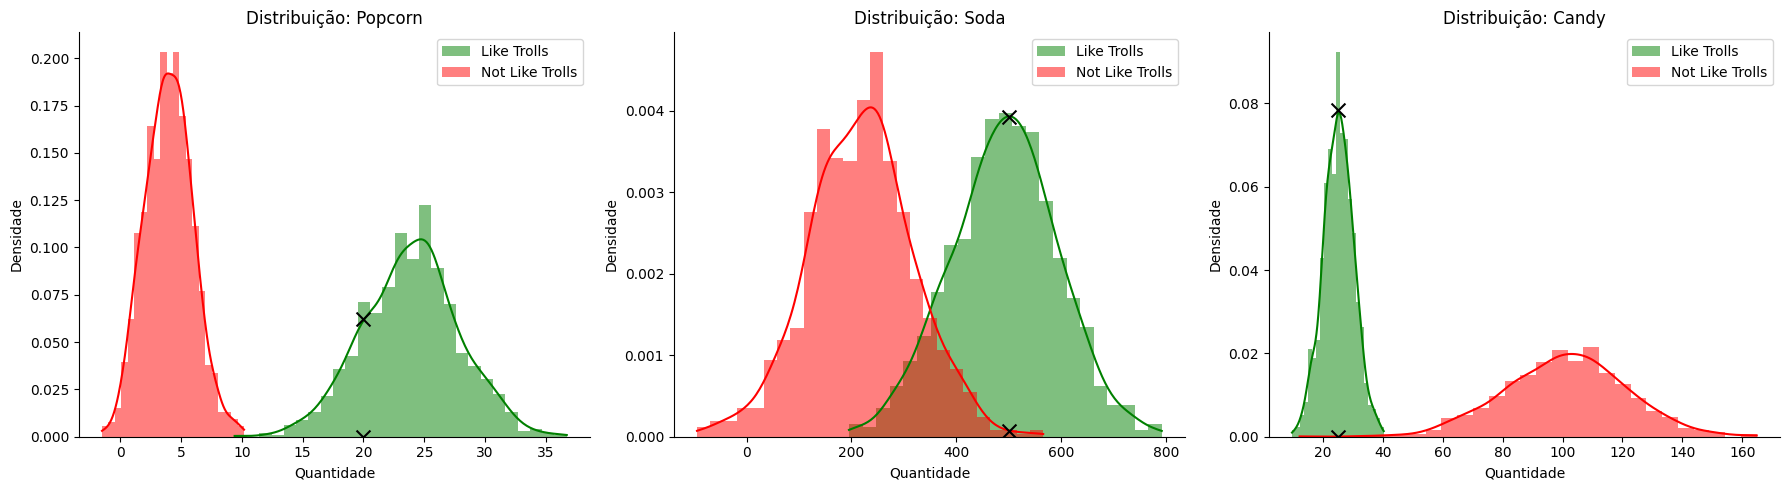

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_kwargs = {
    "kde": True,
    "alpha": 0.5,
    "stat": "density",
    "linewidth": 0
}

LIKE_TROLLS_COLOR: str = "green"
NOT_LIKE_TROLLS_COLOR: str = "red"

# popcorn
sns.histplot(like_trolls_popcorn, ax=axes[0], color=LIKE_TROLLS_COLOR, label='Like Trolls', **plot_kwargs)
sns.histplot(not_like_trolls_popcorn, ax=axes[0], color=NOT_LIKE_TROLLS_COLOR, label='Not Like Trolls', **plot_kwargs)
axes[0].scatter(new_person_popcorn, like_likelihood_popcorn, color='black', s=100, marker='x', zorder=10)
axes[0].scatter(new_person_popcorn, not_like_likelihood_popcorn, color='black', s=100, marker='x', zorder=10)
axes[0].set_title('Distribuição: Popcorn')
axes[0].set_xlabel('Quantidade')
axes[0].set_ylabel('Densidade')
axes[0].legend()

# soda
sns.histplot(like_trolls_soda, ax=axes[1], color=LIKE_TROLLS_COLOR, label='Like Trolls', **plot_kwargs)
sns.histplot(not_like_trolls_soda, ax=axes[1], color=NOT_LIKE_TROLLS_COLOR, label='Not Like Trolls', **plot_kwargs)
axes[1].scatter(new_person_soda, like_likelihood_soda, color='black', s=100, marker='x', zorder=10)
axes[1].scatter(new_person_soda, not_like_likelihood_soda, color='black', s=100, marker='x', zorder=10)
axes[1].set_title('Distribuição: Soda')
axes[1].set_xlabel('Quantidade')
axes[1].set_ylabel('Densidade')
axes[1].legend()

# candy
sns.histplot(like_trolls_candy, ax=axes[2], color=LIKE_TROLLS_COLOR, label='Like Trolls', **plot_kwargs)
sns.histplot(not_like_trolls_candy, ax=axes[2], color=NOT_LIKE_TROLLS_COLOR, label='Not Like Trolls', **plot_kwargs)
axes[2].scatter(new_person_candy, like_likelihood_candy, color='black', s=100, marker='x', zorder=10)
axes[2].scatter(new_person_candy, not_like_likelihood_candy, color='black', s=100, marker='x', zorder=10)
axes[2].set_title('Distribuição: Candy')
axes[2].set_xlabel('Quantidade')
axes[2].set_ylabel('Densidade')
axes[2].legend()

sns.despine()

plt.tight_layout()
plt.show()

# I: Naive Bayes and Iris dataset/Acurácia

<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/i/questao_1.png" width="900">


<img src="https://raw.githubusercontent.com/Arthur-Negrao-Smith/Atividade_2-IA/main/assets/i/questao_2.png" width="900">


## Carregando o modelo

In [7]:
nb_model: GaussianNB = GaussianNB()

## Carregando o _dataset_

Iris é um _dataset_ de flores onde as classes são representadas por características de cada espécime

In [8]:
X, y = load_iris(return_X_y=True) # type: ignore

## Separando os dados de treino e de teste

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

## Normalizando os dados de treino e de teste separadamente

Utilizamos um scaler para normalizar os dados e evitar o vazamento de dados

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Treinamento do modelo

In [11]:
nb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## Avaliação do modelo

As métricas demonstram que o problema é facilmente identificável pelo modelo de Naive Bayes, isso pode ser notado pelas suas métricas altas, como o f1-score e outros

In [12]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.92      1.00      0.96        11
           2       1.00      0.93      0.96        14

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

